# Random Forest

In [19]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix




model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


In [8]:
db = pd.read_csv('standardized_crops.csv')

X = db.drop('label',axis=1)
y = db['label']

X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

model.fit(X_train,y_train)

predictions = model.predict(X_test)
acc_score = accuracy_score(y_test,predictions)
f_score = f1_score(y_test,predictions,average="weighted")
r_score = recall_score(y_test,predictions,average="weighted")
cm = confusion_matrix(y_test,predictions)

print("Predictions : ",predictions)
print("Accuracy Score : ", acc_score)
print("F1 Score :", f_score)
print("recall_score : ", r_score)
print(cm)


Predictions :  ['Jowar (Sorghum)' 'Orange (Santra)' 'Bitter Gourd (Karela)' ...
 'Potato (Aloo)' 'Lentil (Masoor)' 'Brinjal (Eggplant/Baingan)']
Accuracy Score :  0.9977272727272727
F1 Score : 0.9977578304048893
recall_score :  0.9977272727272727
[[25  0  0 ...  0  0  0]
 [ 0 21  0 ...  0  0  0]
 [ 0  0 48 ...  0  0  0]
 ...
 [ 0  0  0 ... 50  0  0]
 [ 0  0  0 ...  0 18  0]
 [ 0  0  0 ...  0  0 52]]


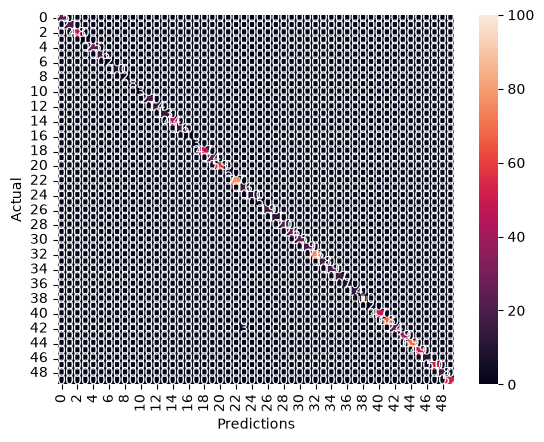

In [12]:
sns.heatmap(cm,fmt="d",annot=True)

plt.xlabel("Predictions")
plt.ylabel("Actual")
plt.show()


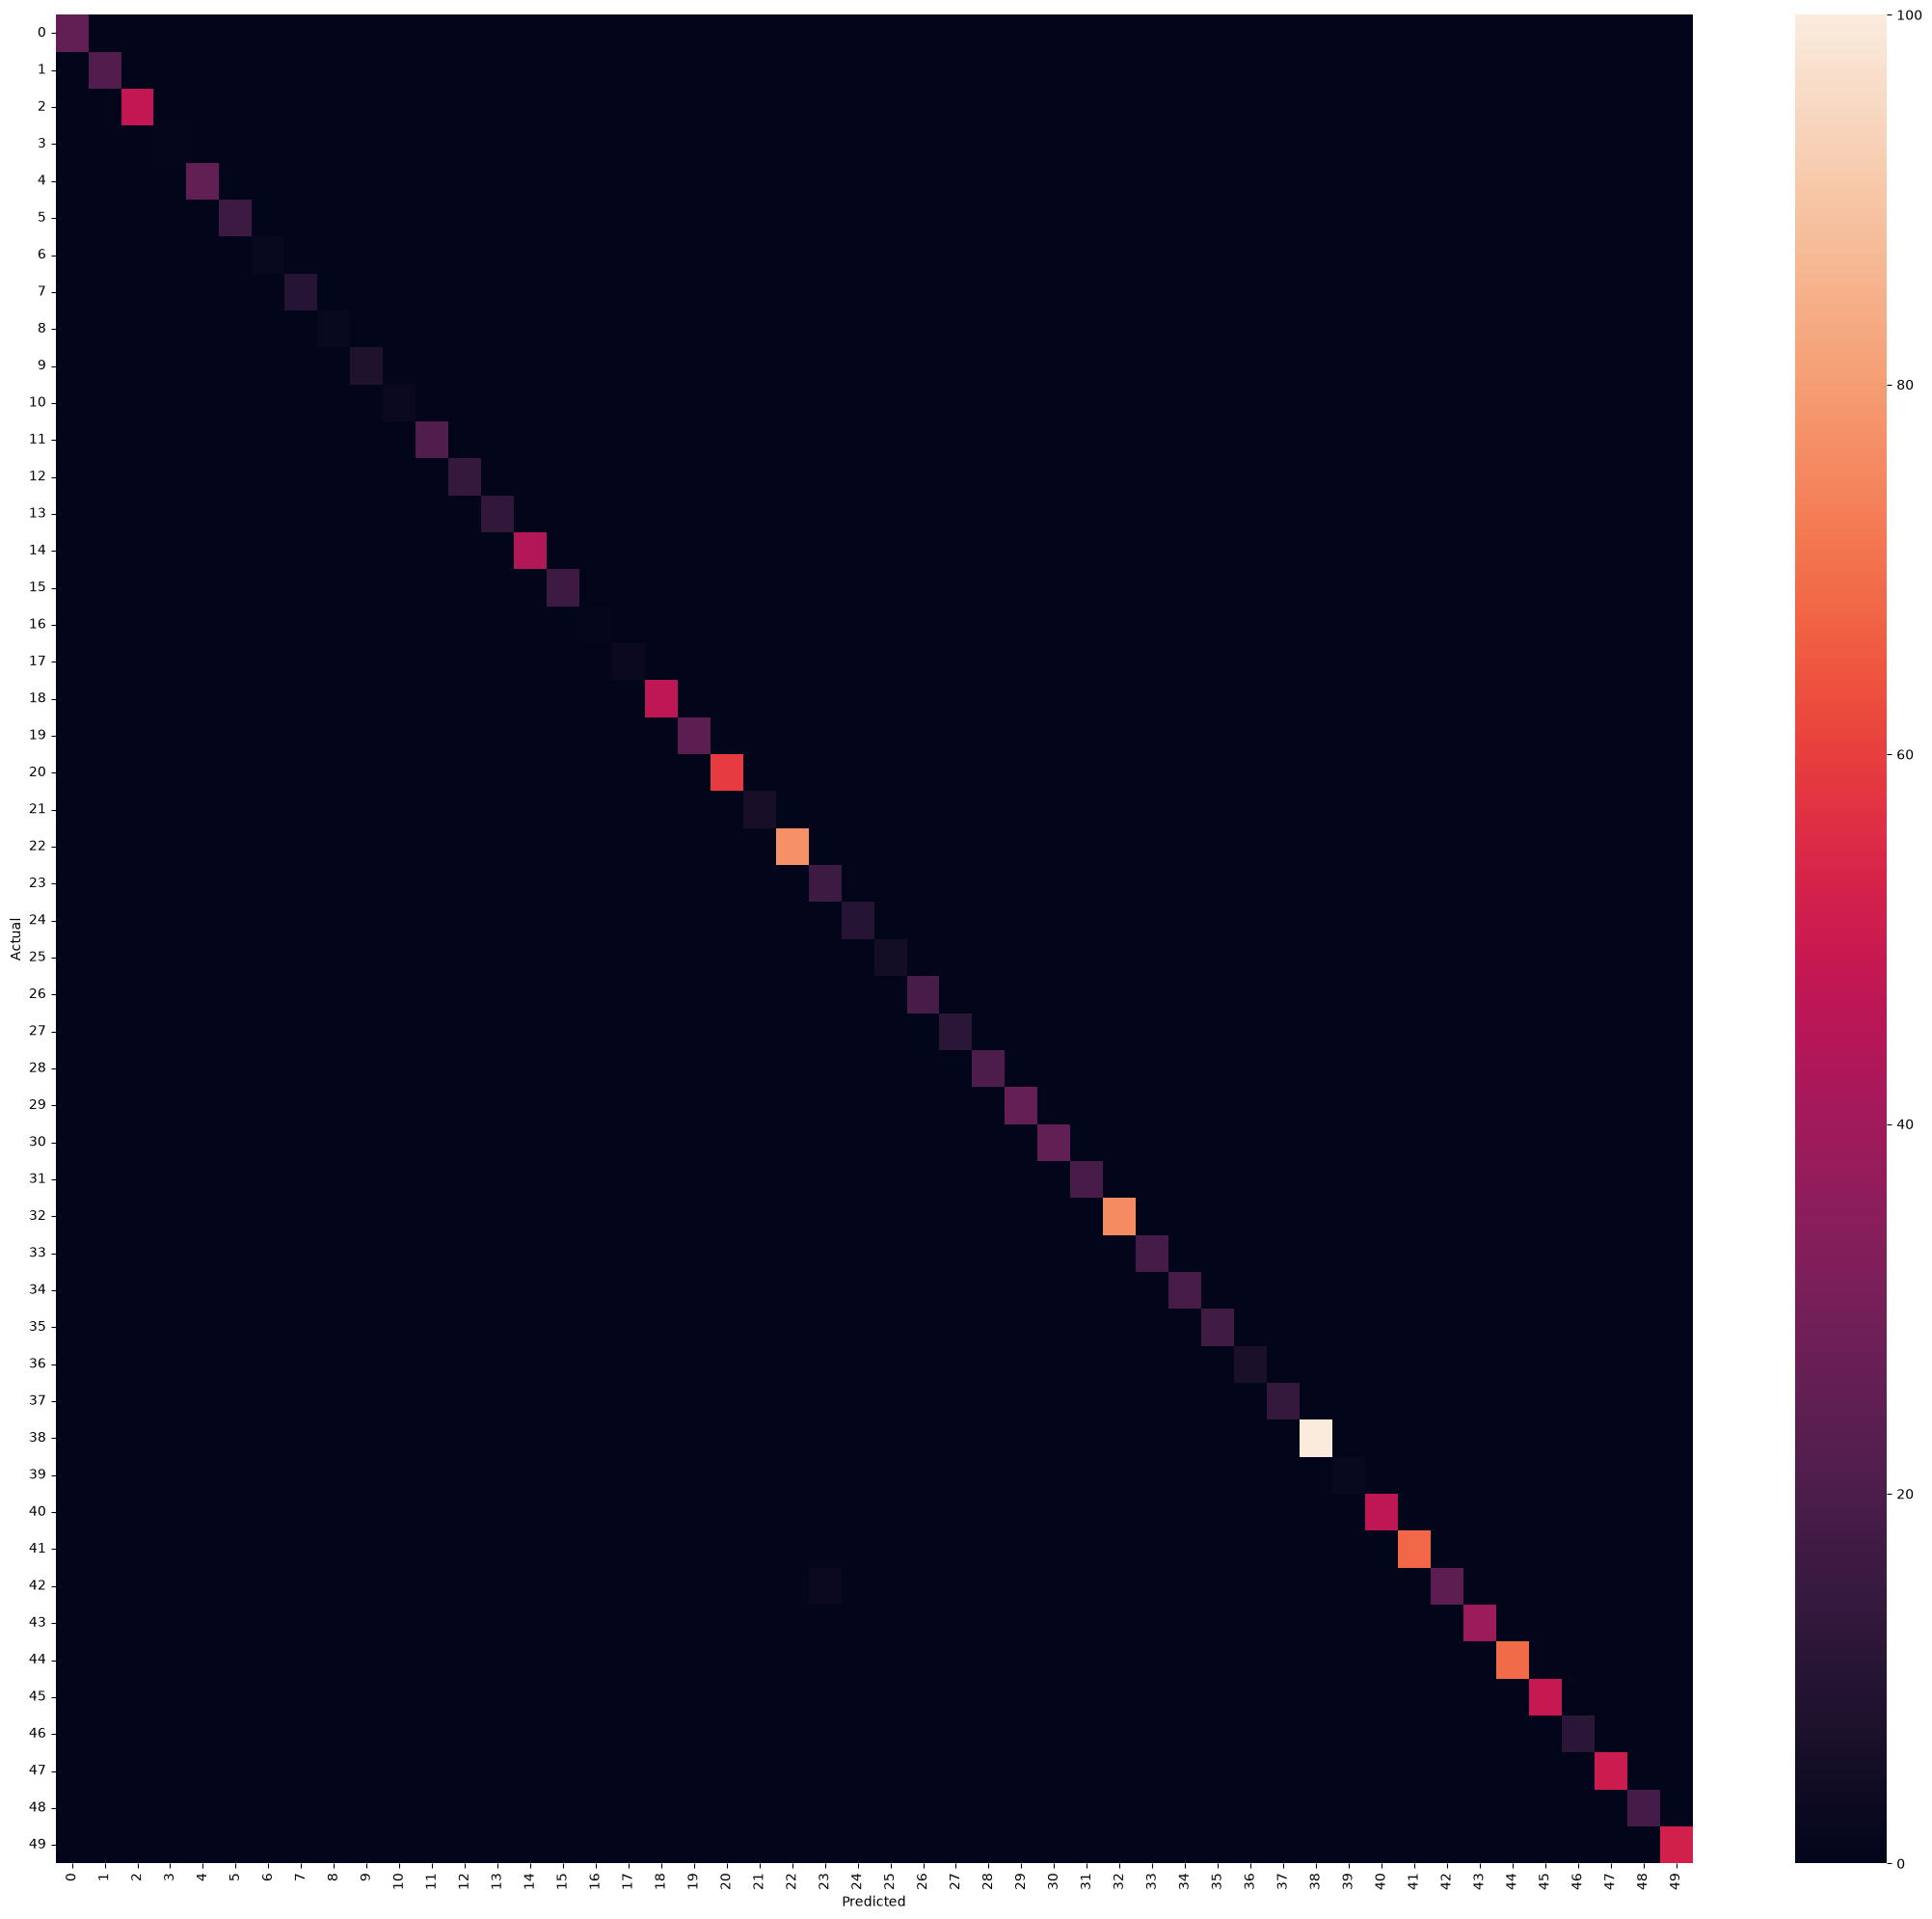

In [18]:
plt.figure(figsize=(22, 20))

sns.heatmap(
    cm,
    annot=False,
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()